In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:
# ============================================
# EMPLOYEE SALARY DATASET GENERATION PROJECT
# ============================================

import pandas as pd
import numpy as np
import random

np.random.seed(42)

num_records = 2500

education_levels = [
    "High School",
    "Bachelor",
    "Master",
    "PhD"
]

job_roles = [
    "Software Engineer",
    "Data Analyst",
    "Data Scientist",
    "Manager",
    "HR",
    "DevOps Engineer"
]

company_types = [
    "Startup",
    "MNC",
    "Government"
]

ages = np.random.randint(21, 60, num_records)
experience = np.random.randint(0, 35, num_records)
education = np.random.choice(education_levels, num_records)
skills_score = np.random.randint(40, 100, num_records)
certifications = np.random.randint(0, 10, num_records)
job_role = np.random.choice(job_roles, num_records)
company_type = np.random.choice(company_types, num_records)

base_salary = 25000

education_bonus = {
    "High School": 0,
    "Bachelor": 10000,
    "Master": 20000,
    "PhD": 35000
}

job_bonus = {
    "Software Engineer": 25000,
    "Data Analyst": 15000,
    "Data Scientist": 35000,
    "Manager": 40000,
    "HR": 10000,
    "DevOps Engineer": 30000
}

company_bonus = {
    "Startup": 5000,
    "MNC": 15000,
    "Government": 10000
}

salary = []

for i in range(num_records):

    emp_salary = (
        base_salary +
        (experience[i] * 2500) +
        (skills_score[i] * 700) +
        (certifications[i] * 3000) +
        education_bonus[education[i]] +
        job_bonus[job_role[i]] +
        company_bonus[company_type[i]] +
        np.random.randint(-10000, 10000)
    )

    salary.append(emp_salary)

employee_df = pd.DataFrame({
    "Age": ages,
    "Education": education,
    "Experience": experience,
    "SkillsScore": skills_score,
    "Certifications": certifications,
    "JobRole": job_role,
    "CompanyType": company_type,
    "Salary": salary
})

employee_df.loc[
    employee_df.sample(frac=0.02).index,
    "SkillsScore"
] = np.nan

employee_df.loc[
    employee_df.sample(frac=0.02).index,
    "Education"
] = np.nan

duplicates = employee_df.sample(20)
employee_df = pd.concat([employee_df, duplicates])

employee_df.to_csv("employee_salary_dataset.csv", index=False)

print("Dataset Generated Successfully!")
employee_df.head()

Dataset Generated Successfully!


,Age,Education,Experience,SkillsScore,Certifications,JobRole,CompanyType,Salary
0,59,High School,16,47.0,0,Manager,Government,142121
1,49,Master,23,72.0,0,HR,MNC,174443
2,35,Master,33,92.0,7,Data Scientist,MNC,270842
3,28,Master,27,46.0,1,Software Engineer,Startup,181712
4,41,Master,21,77.0,0,Software Engineer,MNC,183521


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("employee_salary_dataset.csv")

df["Education"].fillna(
    df["Education"].mode()[0],
    inplace=True
)

df["SkillsScore"].fillna(
    df["SkillsScore"].mean(),
    inplace=True
)

df.drop_duplicates(inplace=True)

df = df[(df["Age"] >= 18) & (df["Age"] <= 65)]
df = df[df["Experience"] >= 0]
df = df[df["Salary"] > 0]

label_encoder = LabelEncoder()

categorical_columns = [
    "Education",
    "JobRole",
    "CompanyType"
]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

scaler = StandardScaler()

numerical_columns = [
    "Age",
    "Experience",
    "SkillsScore",
    "Certifications"
]

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

df.to_csv(
    "processed_employee_salary.csv",
    index=False
)

print("Preprocessing Completed!")
df.head()

Preprocessing Completed!


/tmp/ipykernel_2486/3938539003.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Education"].fillna(
/tmp/ipykernel_2486/3938539003.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: v

,Age,Education,Experience,SkillsScore,Certifications,JobRole,CompanyType,Salary
0,1.655649,1,-0.117063,-1.294482,-1.570843,4,0,142121
1,0.769213,2,0.582597,0.179157,-1.570843,3,1,174443
2,-0.471796,2,1.582112,1.358068,0.841597,1,1,270842
3,-1.092301,2,0.982403,-1.353427,-1.226209,5,2,181712
4,0.060065,2,0.382694,0.473885,-1.570843,5,1,183521


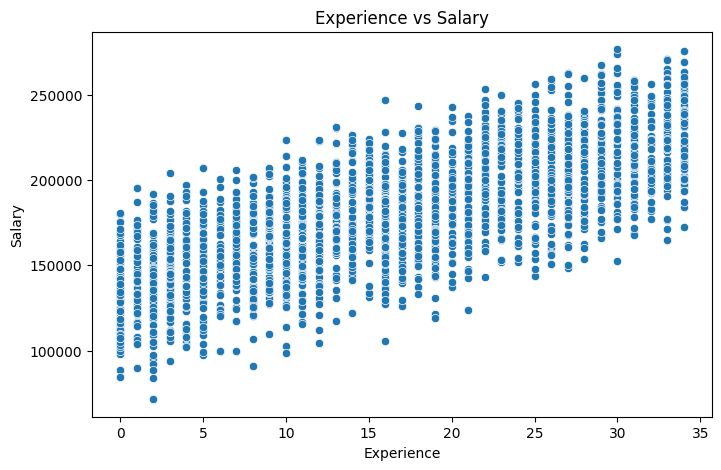

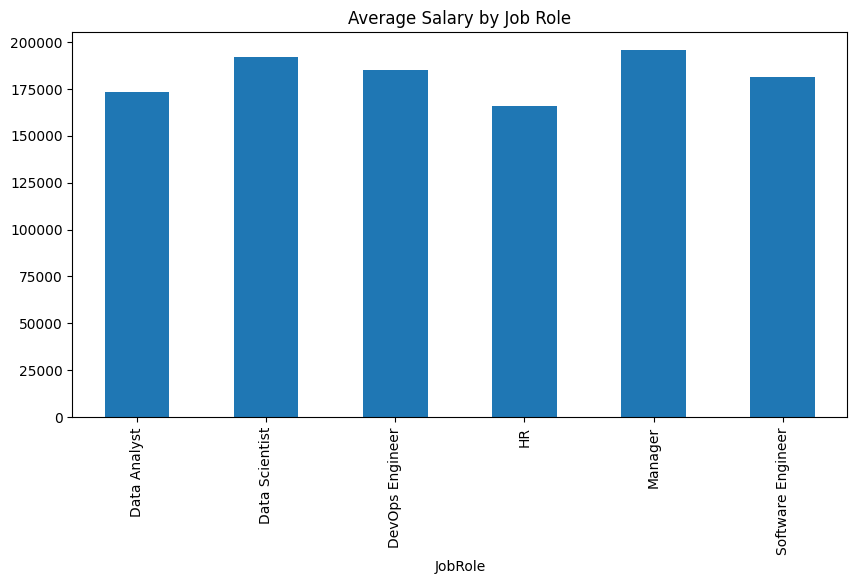

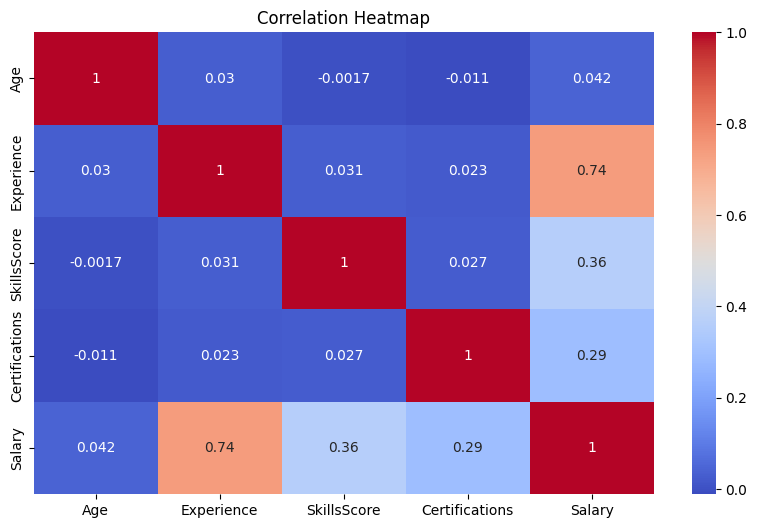

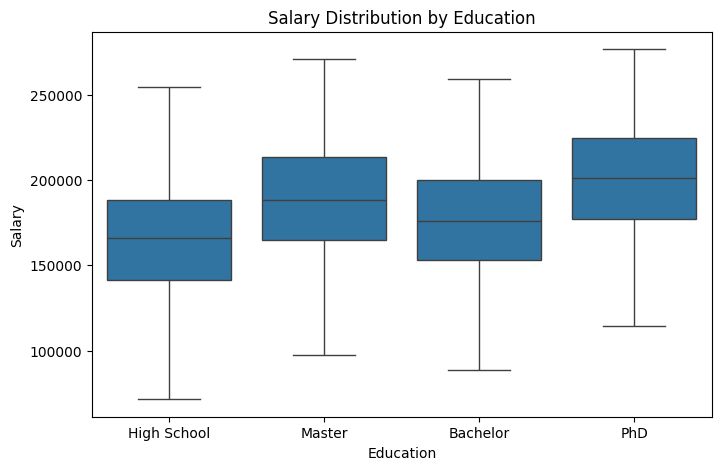

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("employee_salary_dataset.csv")

plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Experience",
    y="Salary",
    data=df
)
plt.title("Experience vs Salary")
plt.show()

plt.figure(figsize=(10,5))
df.groupby("JobRole")["Salary"].mean().plot(
    kind="bar"
)
plt.title("Average Salary by Job Role")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Education",
    y="Salary",
    data=df
)
plt.title("Salary Distribution by Education")
plt.show()

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv(
    "processed_employee_salary.csv"
)

X = df.drop("Salary", axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 9561.85606
RMSE: 12159.756532814157
R2 Score: 0.8863874125118242


In [6]:
age = 30
education = 2
experience = 5
skills_score = 85
certifications = 3
job_role = 1
company_type = 1

input_data = pd.DataFrame([{
    "Age": age,
    "Education": education,
    "Experience": experience,
    "SkillsScore": skills_score,
    "Certifications": certifications,
    "JobRole": job_role,
    "CompanyType": company_type
}])

predicted_salary = model.predict(input_data)

print(
    f"Predicted Salary: ₹{predicted_salary[0]:,.2f}"
)

Predicted Salary: ₹247,630.61


In [7]:
  from google.colab import files

files.download(
    "employee_salary_dataset.csv"
)

files.download(
    "processed_employee_salary.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
readme_content = """
# Employee Salary Prediction System

## Project Overview

The Employee Salary Prediction System is a Machine Learning project designed to predict employee salaries based on various factors such as age, education level, years of experience, skills score, certifications, job role, and company type.

The objective of this project is to understand the complete machine learning workflow, including data generation, preprocessing, exploratory data analysis, visualization, model training, evaluation, and salary prediction.

---

## Dataset Generation / Loading Process

A synthetic dataset containing 2500 employee records was generated using Python libraries such as NumPy and Pandas.

The dataset includes the following features:

* Age
* Education
* Experience
* SkillsScore
* Certifications
* JobRole
* CompanyType
* Salary (Target Variable)

Salary values were generated using realistic factors such as experience, education level, skills score, certifications, job role, and company type. Missing values and duplicate records were intentionally added to demonstrate data preprocessing techniques.

---

## Libraries Used

The following Python libraries were used in this project:

* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn

Machine Learning Algorithms:

* Random Forest Regressor

Evaluation Metrics:

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* R² Score

---

## Steps to Run the Project

1. Generate the employee dataset.
2. Perform data preprocessing:

   * Handle missing values
   * Remove duplicate records
   * Encode categorical features
   * Scale numerical features
3. Perform Exploratory Data Analysis (EDA).
4. Create visualizations for salary trends and feature relationships.
5. Split the dataset into training and testing sets.
6. Train the Random Forest Regression model.
7. Evaluate the model using MAE, RMSE, and R² Score.
8. Run the salary prediction system and provide employee details as input.
9. Obtain the predicted employee salary.

---

## Key Insights from Analysis

* Employees with more years of experience generally earn higher salaries.
* Higher education levels such as Master's and PhD tend to receive higher salaries.
* Job roles significantly influence salary levels.
* Skills score and certifications positively impact employee salaries.
* Company type also contributes to salary variation.
* Experience and skills score showed strong positive correlation with salary.

---

## Model Performance Summary

The Random Forest Regressor was used to predict employee salaries.

Evaluation Metrics Used:

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* R² Score

The model achieved strong prediction performance and was able to accurately estimate salaries based on employee attributes.

---

## Project Files

* Employee_Salary_Prediction.ipynb
* employee_salary_dataset.csv
* processed_employee_salary.csv
* README.md

---

## Author

Aashish kotha

Machine Learning Internship Project – Infobharat Interns

"""

with open("README.md", "w") as file:
    file.write(readme_content)

print("README.md created successfully!")


README.md created successfully!


In [12]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>